In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

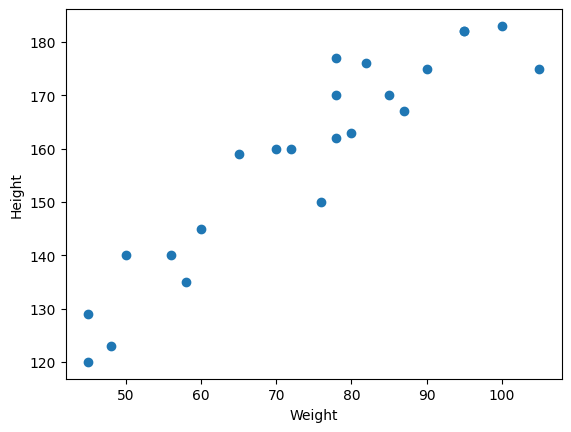

In [5]:
##scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [6]:
##Correleation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


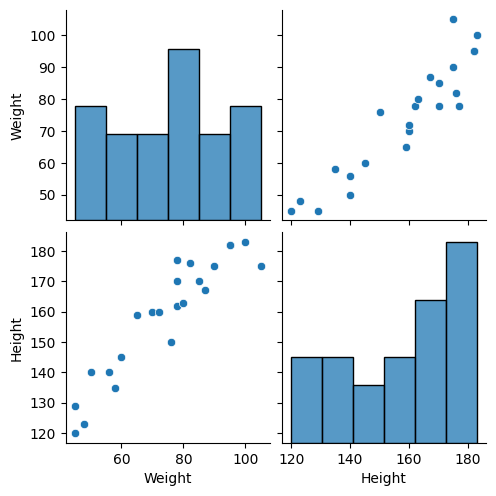

In [7]:
##Seaborn for visualisation
import seaborn as sns
sns.pairplot(df)

In [12]:
##independent and dependent features
##independent features should be dataframe or two dimension
X=df[['Weight']]##dataframe format
np.array(X).shape
Y=df['Height']##dependent features can in be series
np.array(Y).shape


(23,)

In [14]:
pip install scikit-learn

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
from sklearn.model_selection import train_test_split

In [8]:
import pandas as pd
df=pd.read_csv('height-weight.csv')
X=df[['Weight']]
Y=df['Height']
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=42
)

In [9]:
X_train.shape ##it should be 2 Dimension

(18, 1)

In [10]:
##Standardization
from sklearn.preprocessing import StandardScaler


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
df=pd.read_csv('height-weight.csv')
X=df[['Weight']]
Y=df['Height']
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=42
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # for training we use fit_transform
X_test = scaler.transform(X_test)  # for testing we use transform only


In [15]:
X_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

In [16]:
from sklearn.linear_model import LinearRegression

# initializing the object
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print("Slope",regression.coef_)
print("Interception",regression.intercept_)

Slope [17.03440872]
Interception 157.5


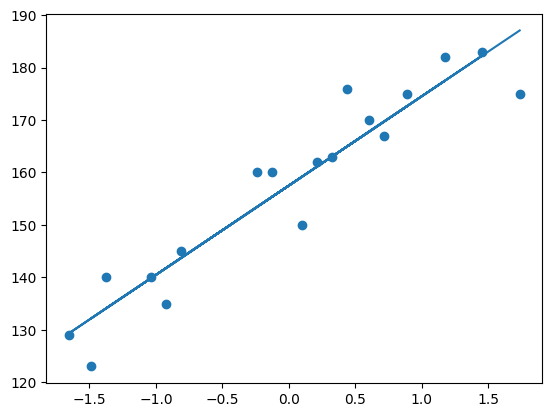

In [ ]:
##Plot training data plot best fit line
import matplotlib.pyplot as plt
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))##Best fit line

In [21]:
##prediction for test data
y_pred=regression.predict(X_test)

In [27]:
##Performance matrix
import numpy as np
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [ ]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.776986986042344


In [30]:
# Adjusted R2 Formula
1 - ((1 -score) * (len(y_test)) / (len(y_test)-X_test.shape[1]-1))

0.6283116434039067